In [1]:
# Set up the file path
import os
os.chdir('..')

In [2]:
# Import packages
import numpy as np
from itertools import product
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

In [3]:
# Create mass-action reactions
r1 = MassAction([], ['Z_1'], ['u_1'], [10.])
r2 = MassAction(['X_2'], ['X_2', 'Z_2'], [None], [2])
r3 = MassAction(['Z_1', 'Z_2'], [], [None], [100])
r4 = MassAction(['Z_1'], ['Z_1', 'X_1'], [None], [3])
r5 = MassAction(['X_1'], ['X_1', 'X_2'], [None], [2])
r6 = MassAction(['X_1'], [], [None], [2])
r7 = MassAction(['X_2'], [], [None], [2])

In [4]:
# Create and compile the IOCRN
iocrn = IOCRN(reactions=[r1, r2, r3, r4, r5, r6, r7], output_labels=['X_1', 'X_2', 'Z_1', 'Z_2'])
iocrn.compile()
print(iocrn)

Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
Output Species: ['X_1', 'X_2', 'Z_1', 'Z_2'] 
∅ ----> Z_1;  [MAK(10.0, u_1)]
X_2 ----> X_2 + Z_2;  [MAK(2)]
Z_1 + Z_2 ----> ∅;  [MAK(100)]
Z_1 ----> X_1 + Z_1;  [MAK(3)]
X_1 ----> X_1 + X_2;  [MAK(2)]
X_1 ----> ∅;  [MAK(2)]
X_2 ----> ∅;  [MAK(2)]


In [5]:
# Construct initial conditions
ic = IC(iocrn.species_labels, values= [
    [0, 0, 0, 0],
])
x0_list = ic.get_ic(iocrn)
print(x0_list)

[array([0, 0, 0, 0])]


In [6]:
# Construct inputs
input_values = [1]
u_list = [np.array(u, dtype=np.float32) for u in product(input_values, repeat=iocrn.num_inputs)]
print(u_list)

[array([1.], dtype=float32)]


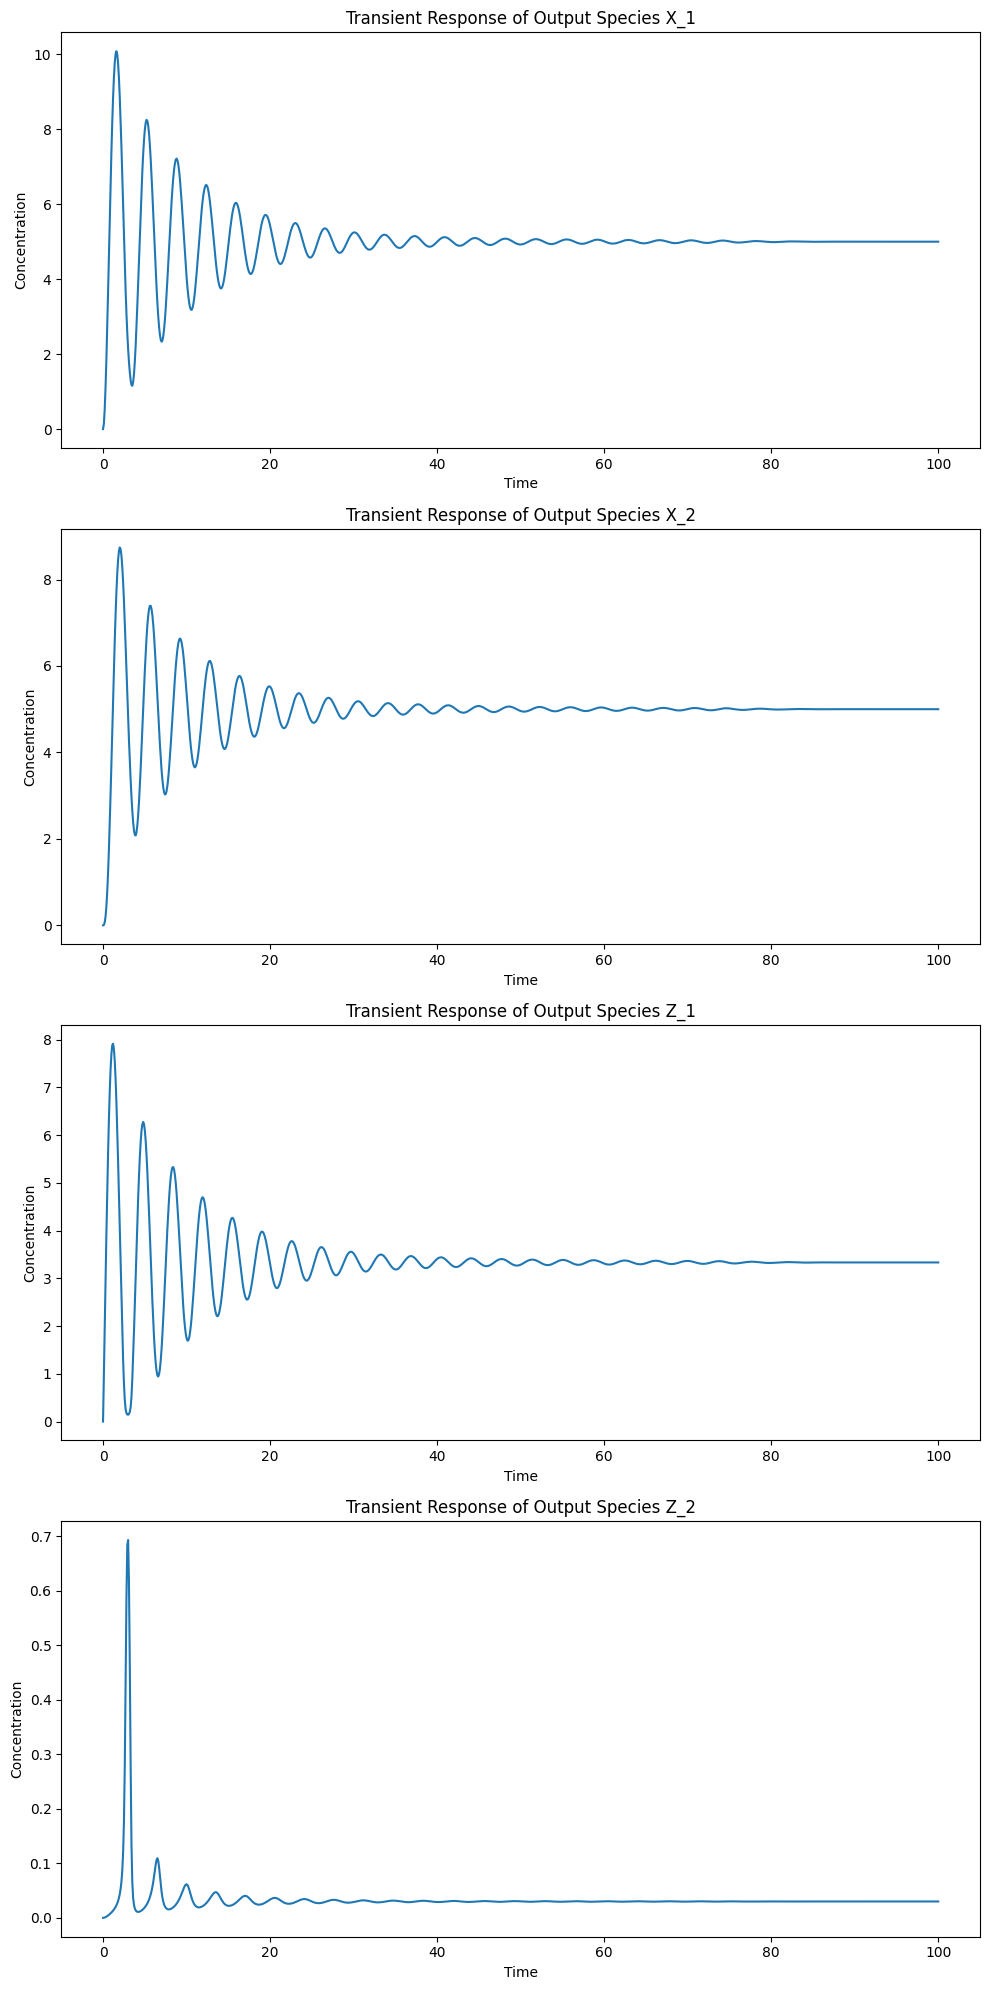

In [7]:
# Simulate Dynamics
time_horizon = np.linspace(0, 100.0, 1000, dtype=np.float32)
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)

# Plot using class method
fig, ax = iocrn.plot_transient_response(alpha = 1)